In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

from hcc_multimodal.transforms import CLINICAL_X_COLUMNS, build_preprocessor, DataType

In [2]:
ROOT = Path().resolve().parents[1]


data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

In [3]:
data.head()

,SID,UCH_ID_lesion,UCH_ID_liver,Age,Weight,Height,Sex,Ethnic Group,Race,"If Other Race, Specify",...,RFS_central,RFS_central_event,vascular_invasion,vascular_invasion_label,resection_score,grading,grade_label,well_grade,moderate_grade,poor_grade
0,1.0,H034,NaN,67.7,NaN,NaN,2.0,NaN,NaN,NaN,...,31.791781,0.0,micro,1.0,0,poor,2.0,0.0,0.0,1.0
1,2.0,H017,L002,75.1,NaN,NaN,1.0,NaN,NaN,NaN,...,30.279452,1.0,micro,1.0,rfa,moderate,1.0,0.0,1.0,0.0
2,3.0,H009,NaN,66.0,NaN,NaN,1.0,NaN,NaN,NaN,...,40.865753,1.0,0,0.0,0/rfa,moderate,1.0,0.0,1.0,0.0
3,4.0,H005,L001,69.6,NaN,NaN,1.0,NaN,NaN,NaN,...,14.301370,1.0,0,0.0,0,moderate,1.0,0.0,1.0,0.0
4,5.0,H049,L004,59.2,NaN,NaN,1.0,NaN,NaN,NaN,...,24.756164,1.0,0,0.0,0,NaN,0.0,1.0,0.0,0.0


In [4]:
x_columns = CLINICAL_X_COLUMNS

In [5]:
nan_summary = (
    data[list(x_columns.keys())]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="nan_count")
)

nan_summary

,nan_count
grading,10
vascular_invasion_label,5
Child-Pugh,4
Age,0
Sex,0
BCLC Stage,0
Max. Diameter of Largest Lesion,0
HCC Etiology: Hepatitis B,0
HCC Etiology: Hepatitis C,0
HCC Etiology: Alcohol,0


In [6]:
preprocessor = build_preprocessor(x_columns)

In [7]:
y_col = "OS_central_event"

X = data[list(x_columns.keys())]
y = data[y_col]
mask = ~y.isna()
X_clean = X[mask]
y_clean = y[mask]

models = {
    "LR": LogisticRegression(
        l1_ratio=1.0, solver="liblinear", max_iter=1000, random_state=42
    ),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

records = []
fold_records = []
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe,
        X_clean,
        y_clean,
        cv=cv,
        scoring=["roc_auc", "accuracy"],
        return_train_score=True,
    )
    records.append(
        {
            "model": model_name,
            "AUC mean": scores["test_roc_auc"].mean().round(3),
            "AUC std": scores["test_roc_auc"].std().round(3),
            "Accuracy mean": scores["test_accuracy"].mean().round(3),
            "Accuracy std": scores["test_accuracy"].std().round(3),
        }
    )
    for fold_i, (train_auc, test_auc) in enumerate(
        zip(scores["train_roc_auc"], scores["test_roc_auc"])
    ):
        fold_records.append(
            {
                "model": model_name,
                "fold": fold_i + 1,
                "train_auc": train_auc,
                "test_auc": test_auc,
            }
        )

cv_results = pd.DataFrame(records)
fold_df = pd.DataFrame(fold_records)
cv_results

Evaluating LR...
Evaluating RF...


,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,LR,0.649,0.038,0.626,0.031
1,RF,0.679,0.067,0.641,0.020


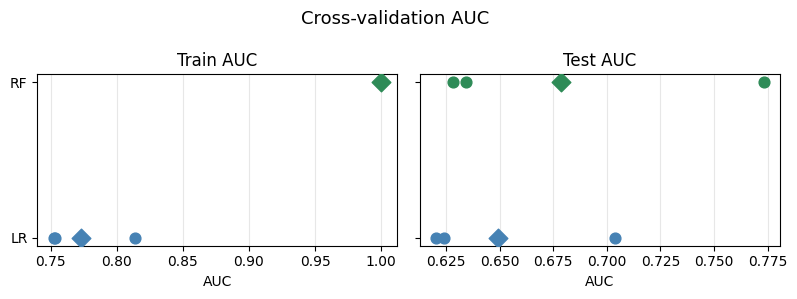

In [8]:
model_names = list(models.keys())
colors = ["steelblue", "seagreen"]
y_pos = np.arange(len(model_names))

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for col, split in enumerate(["train", "test"]):
    ax = axes[col]

    for y, (model_name, color) in enumerate(zip(model_names, colors)):
        df = fold_df[fold_df["model"] == model_name]
        aucs = df[f"{split}_auc"].values

        ax.scatter(aucs, [y] * len(aucs), color=color, s=60, zorder=3)
        ax.scatter(aucs.mean(), y, marker="D", color=color, s=90, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names)
    ax.set_xlabel("AUC")
    ax.set_title(f"{'Train' if split == 'train' else 'Test'} AUC")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Cross-validation AUC", fontsize=13)
plt.tight_layout()
plt.show()

# Feature importance by Random Forest

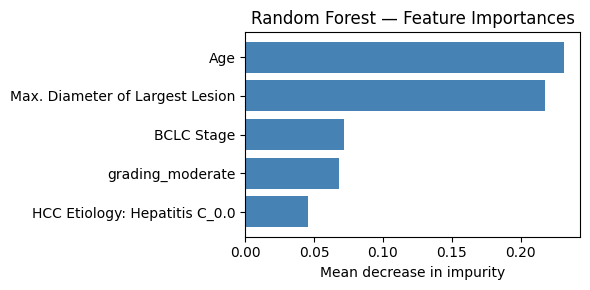

In [10]:
continuous_cols = [col for col, t in x_columns.items() if t == DataType.CONTINUOUS]
categorical_cols = [col for col, t in x_columns.items() if t == DataType.CATEGORICAL]
ordinal_cols = [col for col, t in x_columns.items() if t == DataType.ORDINAL]

full_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]
)
full_pipe.fit(X_clean, y_clean)

ohe = (
    full_pipe.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = continuous_cols + cat_feature_names + ordinal_cols

importances = full_pipe.named_steps["model"].feature_importances_
indices = np.argsort(importances)
top_indices = indices[-5:]
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(
    [feature_names[i] for i in top_indices],
    importances[top_indices],
    color="steelblue",
)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()